In [2]:
from pilot.models        import DeepONet, build_deeponet
from pilot.data          import ODEIterableDataset, LatinHypercubeSampler
from pilot.physics       import harm_osc, ODEsolver

import numpy as np
import matplotlib.pyplot as plt 
import torch
from torch.utils.data import DataLoader

device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Initialize Harmonic Oscillator Object 
k = 2.0
c = 0.1
system = harm_osc([k, c])
solver = ODEsolver(system).solve

# Initialize Sampler Object 
sampler = LatinHypercubeSampler(

    dimensions = 2,
    lows       = [-1.0, -1.0],
    highs      = [1.0, 1.0]
    
)

In [4]:
dataset_size = 1001
batch_size   = 1
num_workers  = 2
t_final      = 10
t_span       = (0, t_final)

osc_dataset = ODEIterableDataset(size          = dataset_size,
                                 system_class  = system,
                                 sampler       = sampler,
                                 t_span        = t_span,
                                 full_solution = True)

osc_loader  = DataLoader(dataset     = osc_dataset,
                         batch_size  = batch_size,
                         num_workers = num_workers)


In [5]:
# Set Up DeepONet configuration 

DEEPONET_CONFIG = {
    
    "hidden_size" : 32,
    "depth"       : 4,
    "latent_size" : 50,
    "input_size_b": 2,
    "input_size_t": 1,
    "output_size" : 1,
    "activation"  : "tanh",

}

# 1. Initialize DeepONet network 

deeponet = build_deeponet(DEEPONET_CONFIG)

# 2. Load the saved weights into the model

state_dict = torch.load("../../weights/best_1d_osc.pth", map_location=device)
deeponet.load_state_dict(state_dict)
deeponet = deeponet.to(device)

# 3. Set to eval mode
deeponet.eval()
_ = 0

In [ ]:
from pilot.benchmark import trajectory 

t, sol, pred = trajectory(deeponet, osc_loader, device)

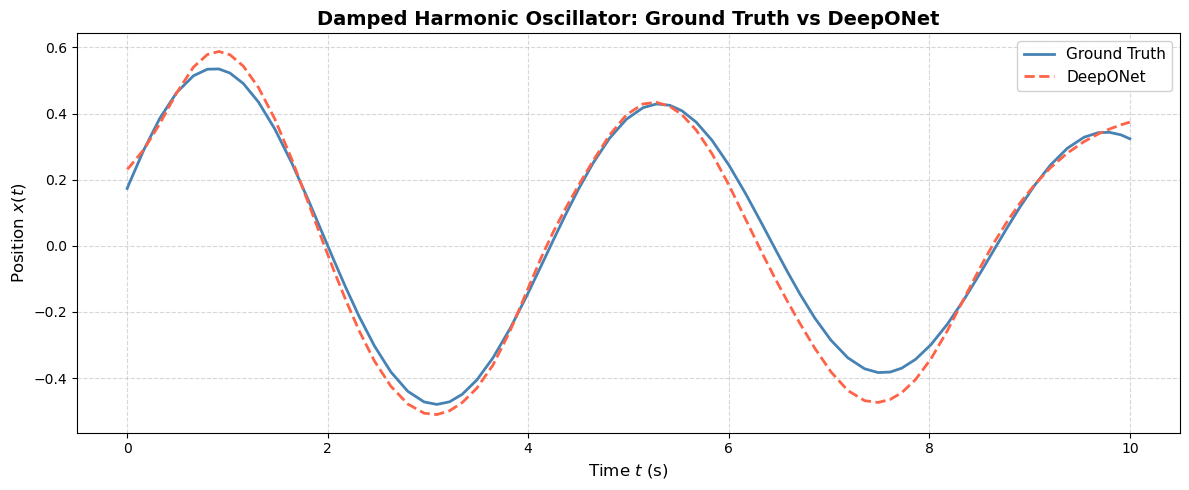

In [11]:
# Plotting 

plt.figure(figsize=(12, 5))
plt.plot(t, sol[0], color="steelblue", lw=2, label="Ground Truth")
plt.plot(t, pred, color="tomato",    lw=2, label="DeepONet", linestyle="--")
plt.title("Damped Harmonic Oscillator: Ground Truth vs DeepONet", fontsize=14, fontweight="bold")
plt.ylabel("Position $x(t)$", fontsize=12)
plt.xlabel("Time $t$ (s)", fontsize=12)
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from pilot.benchmark import timing_data

num_boxes   = 10
num_samples = 1000

nn_timing, solver_timing = timing_data(model       = deeponet, 
                                        ODEsolver   = solver, 
                                        sampler     = sampler,
                                        t_final     = t_final, 
                                        num_samples = num_samples,
                                        num_boxes   = num_boxes, 
                                        device      = device)


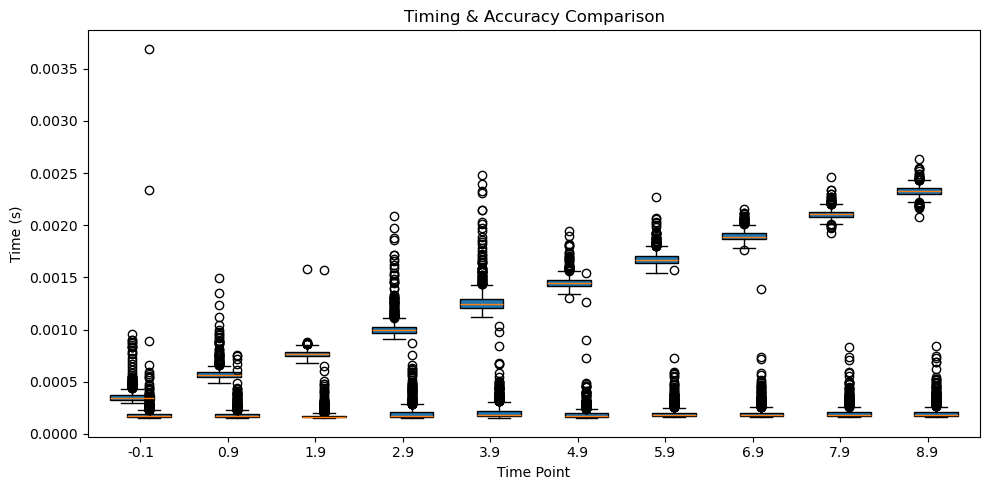

In [13]:
# --- Timing boxplots ---
plt.figure(figsize=(10, 5))

plt.boxplot(solver_timing, 
            positions=np.arange(num_boxes) - 0.1,
            widths=0.5, 
            patch_artist=True)
                  
plt.boxplot(nn_timing, 
            positions=np.arange(num_boxes) + 0.1,
            widths=0.5, 
            patch_artist=True)

plt.xticks(np.arange(num_boxes))
plt.xlabel("Time Point")
plt.ylabel("Time (s)")

plt.title("Timing & Accuracy Comparison")
plt.tight_layout()
plt.show()